# Day 01 — Mô tả dữ liệu và đọc Table 1
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day01.ipynb)

[Slide của buổi học](_static/slides/day01_slides.pptx)

## Mục tiêu

- Đọc đúng cấu trúc dữ liệu cohort
- Tách biến liên tục và biến phân loại
- Tạo được một Table 1 gọn
- Đọc được biểu đồ cơ bản trước khi sang phần mô hình

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import mannwhitneyu

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def raw_url(relative_path):
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{relative_path}"

def load_csv(relative_repo_path):
    local_candidates = [
        Path(relative_repo_path),
        Path("..") / relative_repo_path,
        Path("/content") / REPO_NAME / relative_repo_path,
    ]
    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.read_csv(raw_url(relative_repo_path))

def build_lr_pipeline(feature_list, cat_cols):
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), [c for c in feature_list if c in cat_cols]),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    return pipe

In [2]:
df = load_csv('data/nsclc_egfr_radiomics_simplified.csv')
dictionary = load_csv('data/data_dictionary_nsclc_egfr_radiomics_simplified.csv')
print('Số dòng và số cột', df.shape)
display(df.head())
display(dictionary.head(12))

Số dòng và số cột (200, 32)


,patient_id,age,sex,smoking_status,histology,stage,tumor_size_mm,tumor_volume_cm3,tp53_mutation,egfr_mutation,intra_firstorder_meanHU,intra_firstorder_medianHU,intra_glcm_inverse_difference,intra_gldm_dependence_nonuniformity,intra_gldm_large_dependence_emphasis,ring1_firstorder_meanHU,ring1_firstorder_medianHU,ring1_glcm_inverse_difference,ring1_gldm_dependence_nonuniformity,ring1_gldm_large_dependence_emphasis,ring3_firstorder_meanHU,ring3_firstorder_medianHU,ring3_glcm_inverse_difference,ring3_gldm_dependence_nonuniformity,ring3_gldm_large_dependence_emphasis,ring5_firstorder_meanHU,ring5_firstorder_medianHU,ring5_glcm_inverse_difference,ring5_gldm_dependence_nonuniformity,ring5_gldm_large_dependence_emphasis,intra_shape_sphericity,intra_shape_compactness
0,P001,39,M,Current,Squamous,II,28.0,11.49,0,1,-484.5,-508.2,0.6949,191.39,0.7603,-470.3,-502.5,0.5995,258.06,0.8926,-488.6,-507.9,0.5944,230.55,0.8360,-470.0,-481.0,0.6331,189.54,0.8158,0.7693,0.5633
1,P002,74,M,Never,Squamous,II,34.4,21.31,0,0,-456.0,-462.4,0.6868,149.57,0.6763,-445.0,-461.6,0.7150,187.05,0.7130,-452.6,-462.8,0.7060,184.33,0.7118,-446.6,-456.6,0.6550,177.43,0.7471,0.7740,0.4735
2,P003,68,F,Former,Other,I,38.3,29.42,0,1,-341.8,-348.7,0.7501,178.98,0.6891,-338.6,-349.5,0.6383,178.72,0.7988,-330.7,-332.6,0.6376,189.03,0.7155,-340.4,-350.7,0.6780,169.25,0.7257,0.5048,0.6362
3,P004,57,M,Former,Adenocarcinoma,IV,22.9,6.29,0,0,-382.2,-355.2,0.6963,187.87,0.6591,-364.8,-369.3,0.7057,141.04,0.6235,-374.9,-380.7,0.7013,151.70,0.6670,-365.1,-380.9,0.7117,141.61,0.7134,0.6814,0.5788
4,P005,57,M,Current,Adenocarcinoma,II,43.7,43.70,0,1,-453.8,-471.2,0.6676,163.88,0.7427,-447.2,-474.3,0.6646,173.75,0.7935,-422.3,-467.4,0.6589,161.54,0.7167,-438.9,-465.9,0.7231,175.49,0.7355,0.5880,0.5153


,column,dtype,description
0,patient_id,object,Mã bệnh nhân (synthetic ID)
1,age,int64,Tuổi (years)
2,sex,object,Giới tính sinh học (F/M)
3,smoking_status,object,Tình trạng hút thuốc (Never/Former/Current)
4,histology,object,Giải phẫu bệnh (Adenocarcinoma/Squamous/Other)
5,stage,object,Giai đoạn bệnh (I/II/III/IV - ordinal)
6,tumor_size_mm,float64,Kích thước u (mm) - giả lập
7,tumor_volume_cm3,float64,Thể tích u ước tính (cm^3) từ size - giả lập
8,tp53_mutation,int64,Đột biến TP53 (0/1) - để minh hoạ radiogenomics
9,egfr_mutation,int64,Đột biến EGFR (0/1) - biến mục tiêu


## Bước 1 — Nhìn tổng quát cohort

Buổi này chưa chạy mô hình. Mục tiêu là nắm cohort thật chắc.

Nhóm biến cần nhớ:

- `egfr_mutation` là biến đích
- `age`, `tumor_size_mm`, `tumor_volume_cm3` là biến liên tục
- `sex`, `smoking_status`, `histology`, `stage` là biến phân loại
- `intra_`, `ring1_`, `ring3_`, `ring5_` là các nhóm radiomics

In [3]:
overall_summary = pd.DataFrame({
    'Chỉ số': ['Số bệnh nhân', 'Tuổi trung bình', 'Tỉ lệ nữ', 'EGFR dương', 'Kích thước u trung vị'],
    'Giá trị': [
        len(df),
        f"{df['age'].mean():.1f} ± {df['age'].std():.1f}",
        f"{(df['sex'].eq('F').mean()*100):.1f} phần trăm",
        f"{(df['egfr_mutation'].mean()*100):.1f} phần trăm",
        f"{df['tumor_size_mm'].median():.1f} mm"
    ]
})
display(overall_summary)

,Chỉ số,Giá trị
0,Số bệnh nhân,200
1,Tuổi trung bình,60.4 ± 14.0
2,Tỉ lệ nữ,46.5 phần trăm
3,EGFR dương,45.5 phần trăm
4,Kích thước u trung vị,35.5 mm


## Bước 2 — Tạo Table 1 theo nhóm EGFR

Chỉ chọn một số biến đủ để đọc xu hướng. Không cần nhồi quá nhiều biến ngay từ buổi đầu.

In [4]:
table1 = (
    df.groupby('egfr_mutation')
      .agg(
          age_mean = ('age', 'mean'),
          age_sd = ('age', 'std'),
          tumor_size_median = ('tumor_size_mm', 'median'),
          female_pct = ('sex', lambda s: (s == 'F').mean()*100),
          never_smoker_pct = ('smoking_status', lambda s: (s == 'Never').mean()*100),
      )
      .round(1)
      .rename(index={0:'EGFR âm', 1:'EGFR dương'})
)
display(table1)

,age_mean,age_sd,tumor_size_median,female_pct,never_smoker_pct
egfr_mutation,,,,,
EGFR âm,60.4,13.9,35.5,36.7,33.9
EGFR dương,60.5,14.2,35.9,58.2,47.3


## Bước 3 — Vẽ biểu đồ để nhìn dữ liệu

Ba hình này đủ cho buổi đầu.

- Histogram tuổi
- Bar chart giới tính theo EGFR
- Boxplot kích thước u theo EGFR

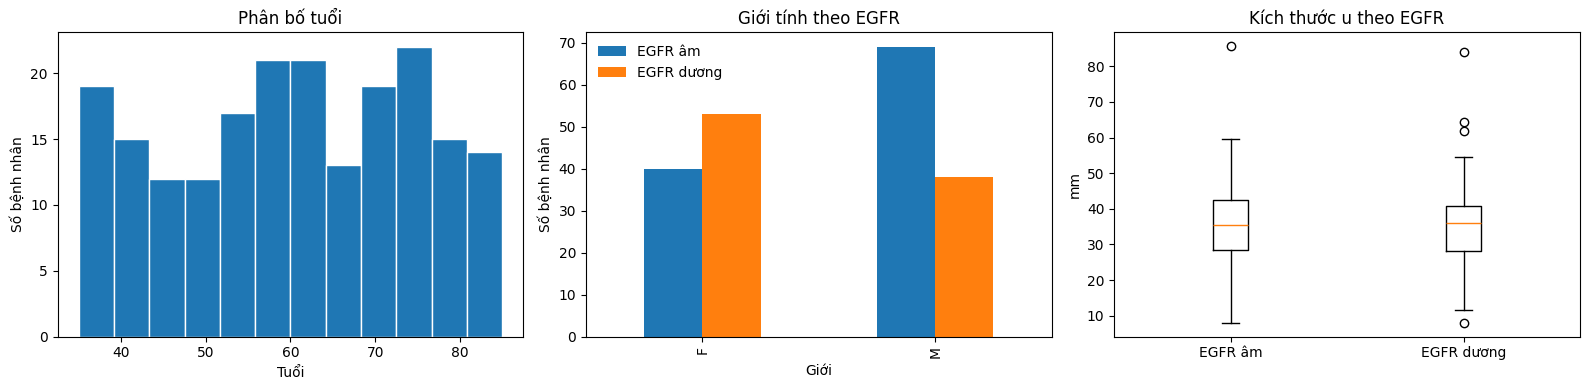

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['age'], bins=12, edgecolor='white')
axes[0].set_title('Phân bố tuổi')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số bệnh nhân')

sex_egfr = pd.crosstab(df['sex'], df['egfr_mutation'])
sex_egfr.columns = ['EGFR âm', 'EGFR dương']
sex_egfr.plot(kind='bar', ax=axes[1])
axes[1].set_title('Giới tính theo EGFR')
axes[1].set_xlabel('Giới')
axes[1].set_ylabel('Số bệnh nhân')
axes[1].legend(frameon=False)

axes[2].boxplot([
    df.loc[df['egfr_mutation']==0, 'tumor_size_mm'],
    df.loc[df['egfr_mutation']==1, 'tumor_size_mm']
], tick_labels=['EGFR âm', 'EGFR dương'])
axes[2].set_title('Kích thước u theo EGFR')
axes[2].set_ylabel('mm')

plt.tight_layout()
plt.show()

## Kết quả demo của Day 01

Từ bộ dữ liệu demo đang dùng trong khóa học có thể đọc nhanh như sau.

- Cohort có 200 bệnh nhân
- Tuổi trung bình là 60.4 và độ lệch chuẩn là 14.0
- Tỉ lệ EGFR dương là 45.5 phần trăm
- Kích thước u trung vị là 35.5 mm

Điều quan trọng ở Day 01 là học sinh phải nói được dữ liệu đang có gì trước khi chạy mô hình.

## Sản phẩm sau bài học

- Một bảng mô tả cohort tổng quát
- Một Table 1 theo nhóm EGFR
- Ba hình cơ bản
- Hai đến ba câu nhận xét ngắn

## Tự kiểm tra

1. Biến đích là biến nào
2. Vì sao phải nhìn dữ liệu trước khi chạy model
3. Nếu bỏ Table 1 thì lúc viết báo cáo sẽ thiếu phần gì